In [1]:
# Predicting Students' Exam Scores Based on Their Daily Habits (e.g. - Study hours per day)

# Problem Statment: 
# This projects explores the correlations between a student's daily habits and their exam socres.
# Specfically, aiming to see if it is possible to determine their exam scores based on their daily habits.
# Planning to make this assement by using linear regression to model the relationship between the number of study hours per day and exam performance. 

# Type of Learning: Supervised Learning  
# Task: Regression  

In [2]:
# Data Description 

# The dataset contains information on students’ daily habits and their performance outcomes. It includes the following features (and more):

# - `study_hours_per_day` (float): Average number of hours a student studies per day.
# - `sleep_hours` (float): Average number of hours of sleep per day.
# - `social_media_hours` (float): Daily social media time not related to studying (in hours).
# - `exercise_frequency` (int): Number of times the student exercises per week.
# - `exam_score` (float/int): Final exam score (target variable).

# Dataset Details:
# - Format: CSV
# - Rows: 1000
# - Columns: 16
# - Data Source: Kaggle.com 
# - Data Link: "http://kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance/data"

In [3]:
# Import libraries
import pandas as pd

In [4]:
# Load the dataset
performance = pd.read_csv("Downloads/student_habits_performance.csv")

In [6]:
# Preview the data
performance.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [7]:
performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [8]:
# Check for missing values
performance.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [9]:
performance[performance.isnull().any(axis=1)]

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
10,S1010,19,Female,4.6,3.7,0.8,No,77.6,5.8,Fair,1,NaN,Good,3,No,63.3
33,S1033,18,Female,4.0,0.9,1.1,No,99.5,5.8,Poor,2,NaN,Average,5,No,70.7
47,S1047,23,Female,2.5,2.9,2.7,No,83.5,7.0,Good,4,NaN,Good,8,Yes,59.7
74,S1074,21,Female,2.3,1.0,0.4,No,100.0,6.4,Fair,6,NaN,Good,1,No,66.9
93,S1093,22,Male,4.1,2.5,3.0,No,85.1,5.8,Good,4,NaN,Good,5,No,70.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
921,S1921,23,Female,4.4,2.7,1.0,No,79.8,6.1,Fair,6,NaN,Average,3,No,85.4
925,S1925,19,Other,1.7,2.9,1.6,Yes,97.3,8.7,Good,1,NaN,Good,7,No,53.6
939,S1939,18,Female,4.7,3.2,1.9,No,75.2,5.4,Good,3,NaN,Good,6,No,71.0
945,S1945,23,Male,6.0,2.9,2.1,Yes,98.9,6.4,Poor,0,NaN,Average,7,No,100.0


In [10]:
# Drop all rows with missing values 
performance = performance.dropna()

In [11]:
# See if there are any duplicated vlaues 
performance.duplicated().sum()

np.int64(0)

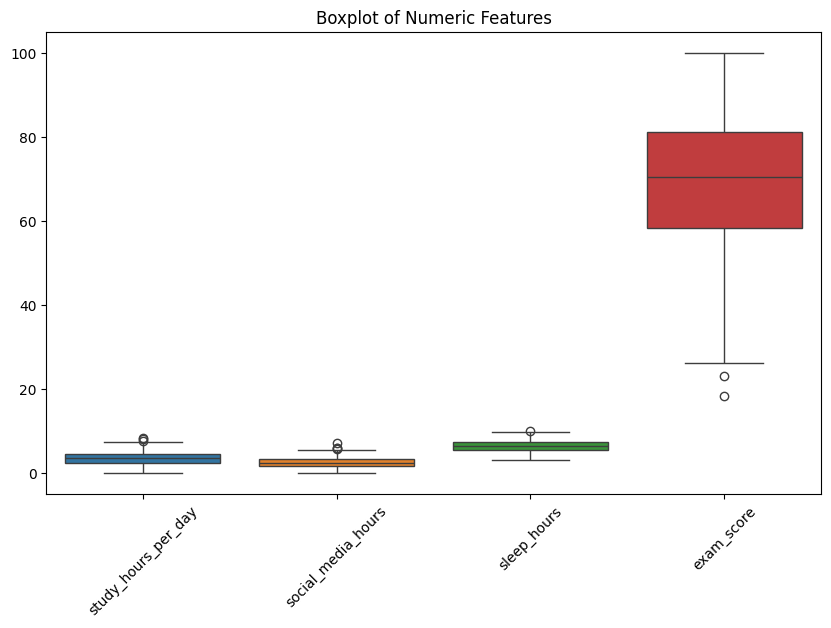

In [12]:
# Check for outliers 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=performance[['study_hours_per_day', 'social_media_hours', 'sleep_hours', 'exam_score']])
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.show()

In [13]:
# Removed insignificant features from data table
performance = performance[["study_hours_per_day","social_media_hours","netflix_hours","attendance_percentage","sleep_hours","exercise_frequency","mental_health_rating","exam_score"]]

In [14]:
# Data Cleaning Summary 
# Handled missing values in data set by dropping NaN values 
# Looked to see if there were any duplicated rows 
# Removed insignificant features from data set
# Reviewed numeric features for outliers using boxplot, but this didn't really provide much information

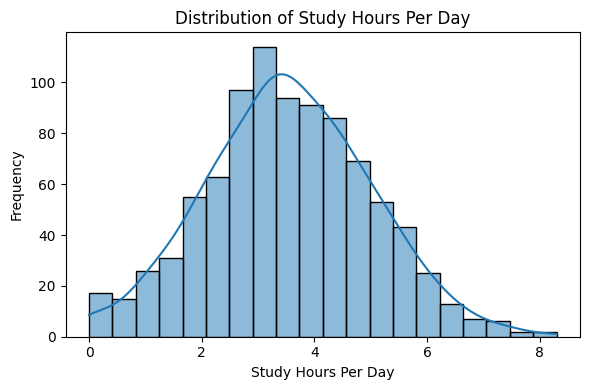

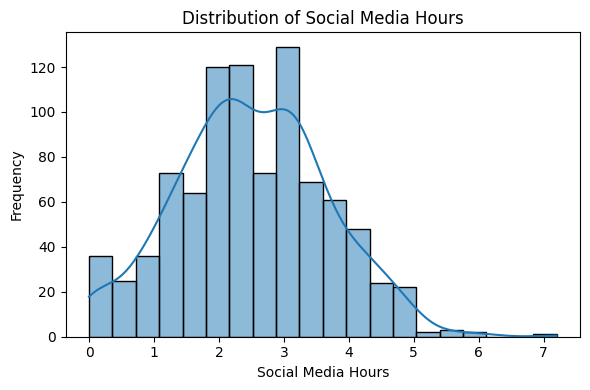

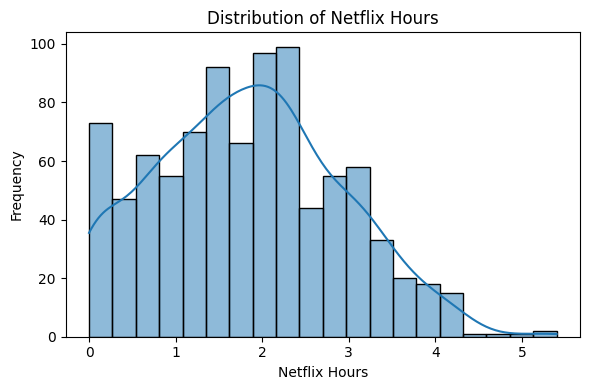

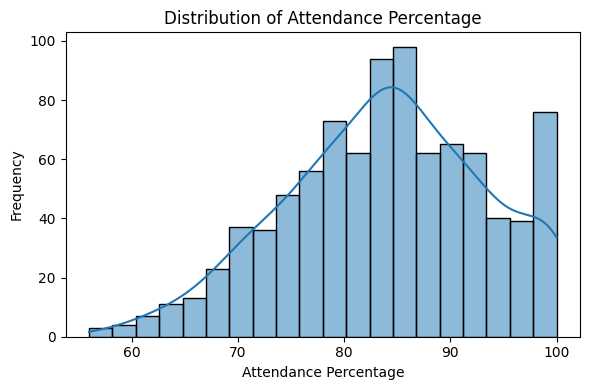

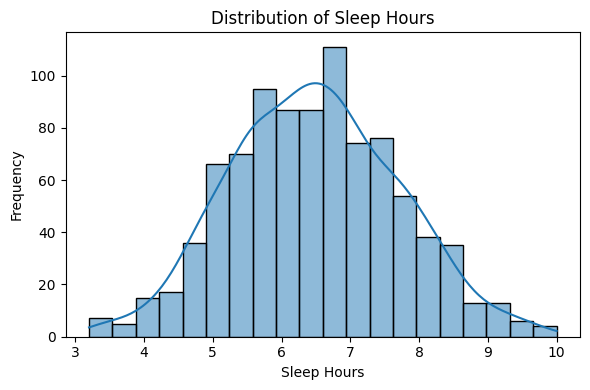

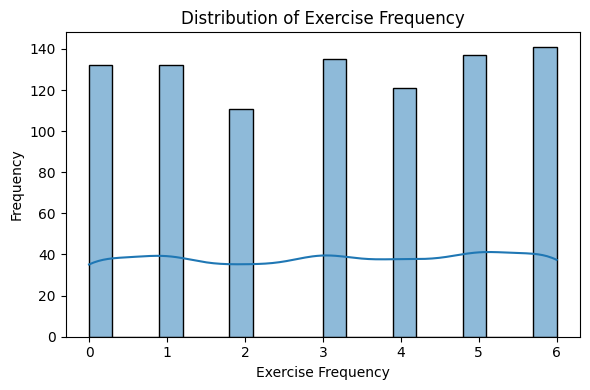

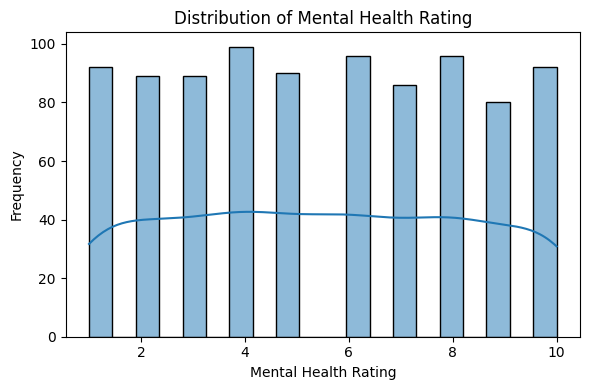

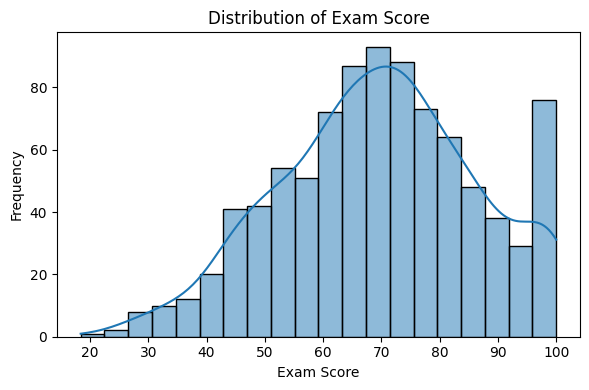

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numeric features 
numeric_features = [
     'study_hours_per_day', 'social_media_hours', 'netflix_hours',
    'attendance_percentage', 'sleep_hours',
    'exercise_frequency', 'mental_health_rating', 'exam_score'
]

# Histograms
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(performance[col], kde=True, bins=20)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


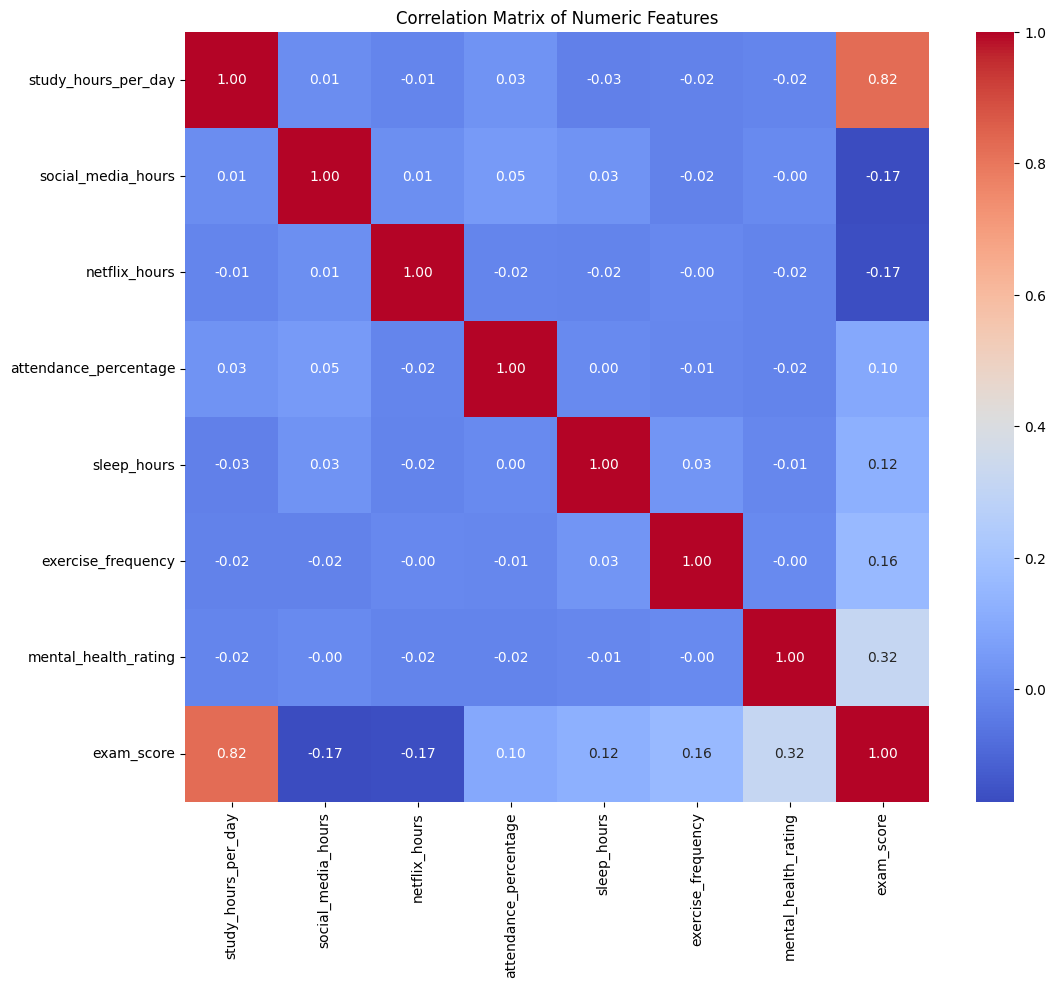

In [16]:
# Correlation matrix of numeric features
plt.figure(figsize=(12, 10))
corr = performance[numeric_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [20]:
# Checking the correlation between all the numeric type fetures and exam_score 
performance.select_dtypes(include='number').corr()["exam_score"]

study_hours_per_day      0.822950
social_media_hours      -0.171672
netflix_hours           -0.166578
attendance_percentage    0.096005
sleep_hours              0.122294
exercise_frequency       0.161397
mental_health_rating     0.317945
exam_score               1.000000
Name: exam_score, dtype: float64

In [19]:
# Exploratory Data Analysis Summary 
# `study_hours_per_day` appears to have a positive linear relationship with `exam_score`, making it a strong candidate for regression modeling.
# Other features like `sleep_hours` and `screen_time` may have weaker or nonlinear relationships.
# The correlation matrix shows that `study_hours_per_day` is the most correlated with the target.


<Axes: ylabel='Frequency'>

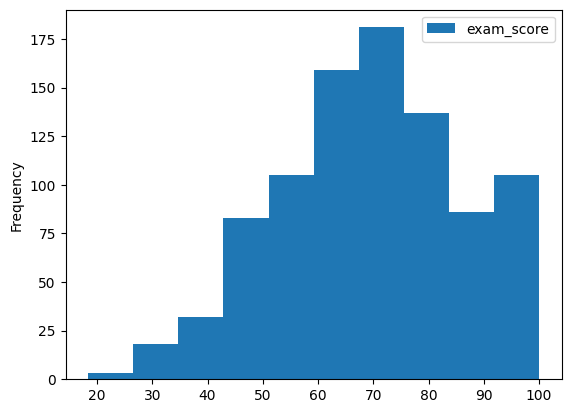

In [21]:
performance.plot.hist(y="exam_score")

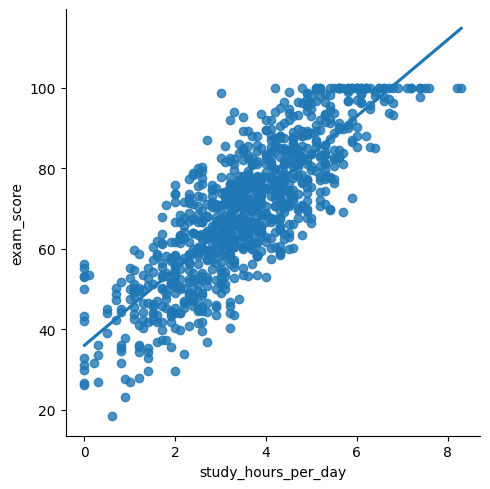

In [22]:
sns.lmplot(x="study_hours_per_day", y="exam_score", data=performance, fit_reg=True, ci=None)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

features = performance [[ "study_hours_per_day", "social_media_hours", "netflix_hours",
    "attendance_percentage", "sleep_hours", "exercise_frequency",
    "mental_health_rating"
]] 

target = performance["exam_score"]

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [24]:
reg = LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [25]:
y_pred = reg.predict(X_test)
print("Linear Regression R²:", r2_score(y_test, y_pred))
print("Linear Regression RMSE:", mean_squared_error(y_test, y_pred, squared=False))


Linear Regression R²: 0.8897165427387148
Linear Regression RMSE: 5.471249791046546


C:\Users\17202\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest R²:", r2_score(y_test, rf_pred))
print("Random Forest RMSE:", mean_squared_error(y_test, rf_pred, squared=False))

Random Forest R²: 0.8791100658145499
Random Forest RMSE: 5.728308875351306


C:\Users\17202\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [27]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(reg, features, target, cv=5, scoring='r2')
print("Linear Regression CV R² mean:", cv_scores.mean())

Linear Regression CV R² mean: 0.8954234373142306


C:\Users\17202\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\17202\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


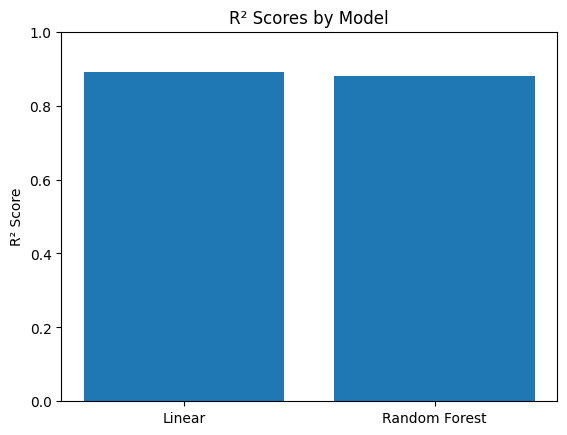

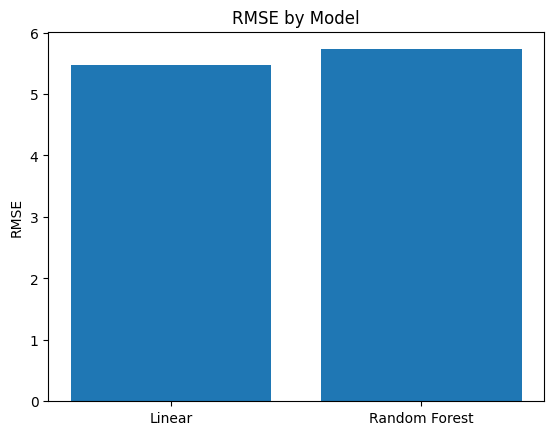

In [28]:
import matplotlib.pyplot as plt

models = ['Linear', 'Random Forest']
r2_scores = [
    r2_score(y_test, y_pred),
    r2_score(y_test, rf_pred)
]
rmse_scores = [
    mean_squared_error(y_test, y_pred, squared=False),
    mean_squared_error(y_test, rf_pred, squared=False)
]

# Plot R²
plt.bar(models, r2_scores)
plt.title("R² Scores by Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.show()

# Plot RMSE
plt.bar(models, rmse_scores)
plt.title("RMSE by Model")
plt.ylabel("RMSE")
plt.show()


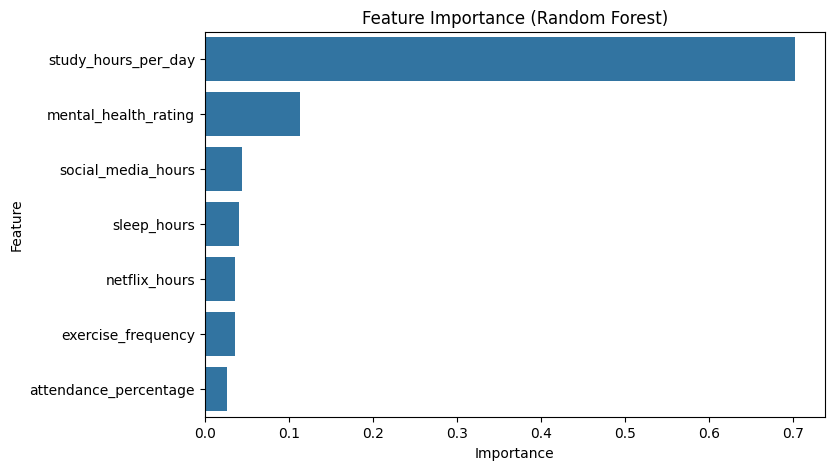

In [29]:
import pandas as pd

# Get feature importances
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': features.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title("Feature Importance (Random Forest)")
plt.show()


In [30]:
# Models summary and Results and Analysis

# Two models were trained: Linear Regression, and Random Forest.
# Cross-validation confirmed the stability of the models.
# Feature importance revealed that `study_hours_per_day`, `mental_health_rating`, and `social_media_hours` are key predictors for `exam_score`.
# The RMSE values indicate that predictions are off by approximately 5 points on average, depending on the model.

In [31]:
# Discussion and Conclusion
# This project aimed to predict students’ exam performance based on daily habits using supervised machine learning models. 
# Through exploratory analysis and multiple regression techniques, I learned that `study_hours_per_day` was the most significant predictor of exam score, which aligns with expectations.

# However, one of the more unexpected insights was that `mental_health_rating` ranked as the second most important predictor — higher than variables like `social_media_hours` and `sleep_hours`, which I initially assumed would have a stronger effect. 
# This suggests that students’ emotional well-being may play a more crucial role in academic success than certain lifestyle habits.

# Model performance improved notably when using Random Forest, which outperformed Linear. 
# This implies that the relationship between predictors and exam scores is likely non-linear and benefits from more complex models.